In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_charge as yuc

yu.setpath('analysis_sgm')
enss=['b','c','d','e']
ylim_global=[0,80]

In [2]:
symmetrizeQ=False
[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl_reg('ens2pars_jk_meffnst_selected',pathlabel='analysis_c2pt')

ens2data={}; ens2Njk={}
for ens in enss:
    path=f'/p/project1/ngff/li47/code/projectData/07_Nsgm/charges/{yu.ens2full[ens]}.h5'
    [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=yuc.load(path,symmetrizeQ=symmetrizeQ)
    ens2data[ens]=[c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]
    ens2Njk[ens]=len(c2pt_disc)

ens2Njk

{'b': 725, 'c': 400, 'd': 493, 'e': 445}

In [3]:
path='data_aux/sgm_ChPT.csv'
df=pd.read_csv(path, index_col=0)
def func(ele):
    m,e=ele.split(',')
    m=m.split('(')[-1]
    e=e.split(')')[0]
    return float(m),float(e)

dic_sgm_ChPT={(row_label, col_label): func(df.loc[row_label, col_label])
    for row_label in df.index
    for col_label in df.columns
}

In [4]:
g='gS+'
ds=1

app = {1:'',2:'_ds2'}[ds]

ens2dics={}
for ens in enss:
    pars_jk_meff2st=ens2pars_jk_meff2st[ens]
    [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
    tf2ratio=key2tf2ratio[g]
    
    tfmins_2st=tfs_conn[:-3]
    # tcmins_2st=np.arange(1,int(0.5/yu.ens2a[ens]),int(0.2/yu.ens2a[ens]))
    tcmins_2st=np.arange(1,round(0.45/yu.ens2a[ens]))
    
    label2fits={}
    for label in ['2st2step_SYM','2st2step_SYMshare','2st2step_SYM_0ra11','2st2step_SYM_0rc1_0ra11','2st2step_SYM_share11']:
        label2fits[label]=yu.doFits_3pt(label,tf2ratio,tfmins_2st,tcmins_2st,pars_jk_meff2st=pars_jk_meff2st,symmetrizeQ=symmetrizeQ,downSampling=[1,ds],label=f'{g}_{ens}_{label}{app}_{symmetrizeQ}',verbose=1)
        
    # n=int(0.2/yu.ens2a[ens])
    n=2
    def dE2lbd(dE):
        lbd0=dE*n
        return np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
    
    def lbd2tf2ratio(dE):    
        lbd=dE2lbd(dE)
        
        tf2ratio={}
        for tf in tfs_conn:
            c3=key2tf2c3pt[g][tf]
            c3=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd**2*c3
            c2=(lbd**2)*c2pt_disc[:,tf]
            tf2ratio[tf]=c3/c2[:,None]
        return tf2ratio
    tfmins=tfmins_2st
    tcmins=[n+tcmin for tcmin in tcmins_2st]
    
    fits_laplace=yu.doFits_3pt_lbd(lbd2tf2ratio,tfmins,tcmins,symmetrizeQ=symmetrizeQ,label=f'{g}_{ens}_lbd{app}_{symmetrizeQ}',verbose=1,downSampling=[1,ds],overwrite=False)
    fits_laplace=[[(tfmin,tcmin),np.array([pars_jk[:,0],np.abs(pars_jk[:,1])]).T,chi2_jk,Ndof] for (tfmin,tcmin),pars_jk,chi2_jk,Ndof in fits_laplace]

    fitlabel_chosen=(8,n+2)
    # fitlabel_chosen=fits_laplace_ds2[0][0]
    fit_MA_laplace=yu.doMA_3pt(fits_laplace,fitlabels=fitlabel_chosen)
    print(ens,fitlabel_chosen,yu.jackme_un2str(fit_MA_laplace[0][:,1]*yu.ens2aInv[ens]))

    dE=np.mean(fit_MA_laplace[0][:,1])
    tf2ratio_laplace=lbd2tf2ratio(dE)
    # fits_const_2=yu.doFits_3pt('const',tf2ratio_laplace,tfmins,tcmins,symmetrizeQ=symmetrizeQ,label=f'const_2_laplace'+extraLabel)
    # fit_const_MA_2=yu.doMA_3pt(fits_const_2,fitlabels=fitlabel_chosen)

    xunit=yu.ens2a[ens]
    yunit=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]
    
    dic={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,None,None,None,None],
        'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
        'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,1,None],
        'xyunit':[xunit,yunit],
        'mfc:[global]':['None'],
    }
    dic_lbd={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio_laplace,None,fits_laplace,None,None],
        'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
        'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,n+1,None],
        'xyunit':[xunit,yunit],
        'mfc:[global]':['white'],
    }
    
    label2dic={}
    for label in label2fits.keys():
        label2dic[label]={
            'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[None,None,None,None,label2fits[label]],
            'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
            'fit_2st:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,None,5,None,None],
            'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,1,None],
            'xyunit':[xunit,yunit],
            'mfc:[global]':['None'],
        }
    
    ens2dics[ens]=[dic,dic_lbd,label2dic]

colHeaders=['ratio','fit_laplace','2st2step_SYM','2st2step_SYM_0ra11','2st2step_SYM_0rc1_0ra11','2st2step_SYM_share11']
fig,axs=yu.makePlot_3pt([ens2dics[ens][0] for ens in enss],shows=['rainbow'],colHeaders=colHeaders,fontsize_colHeaders=20, sharey=True)
yu.addRowHeader(axs,[yu.ens2label[ens] for ens in enss])
axs[0,0].set_ylim([0,80])
fig,axs=yu.makePlot_3pt([ens2dics[ens][1] for ens in enss],shows=['rainbow']+[None]*(colHeaders.index('fit_laplace')-1)+['fit_const'],figAxs=(fig,axs),colHeaders=None)

for i,label in enumerate(colHeaders):
    if label in label2dic.keys(): 
        fig,axs=yu.makePlot_3pt([ens2dics[ens][2][label] for ens in enss],shows=['rainbow']+[None]*(i-1)+['fit_2st'],figAxs=(fig,axs),colHeaders=None)
fig,axs=yu.makePlot_3pt([ens2dics[ens][2]['2st2step_SYMshare'] for ens in enss],shows=['rainbow','fit_2st'],figAxs=(fig,axs),colHeaders=None)
        
yu.finalizePlot(f'rainbow_fits{app}')

b (8, 4) 347(24)
c (8, 4) 395(26)
d (8, 4) 385(22)
e (8, 4) 433(30)


In [5]:
ylim=[0,80]

tfphys=[0.4,0.5,0.6,0.7,0.8,0.9]
tcphys=[0.1,0.15,0.2,0.25,0.3,0.35,0.4]
tftcphys=[(tfphy,tcphy) for tfphy in tfphys for tcphy in tcphys if tfphy>=2*tcphy]

labels=['lbd']+['2st2step_SYM','2st2step_SYMshare','2st2step_SYM_0ra11','2st2step_SYM_0rc1_0ra11','2st2step_SYM_share11']

def run(tfphy,tcphy):
    label2res={}
    fig,axs=yu.getFigAxs(1,len(labels),sharex=True,sharey=True)
    axs[0,0].set_ylim(ylim)
    yu.addColHeader(axs,labels)
    for ilabel,label in enumerate(labels):
        ax=axs[0,ilabel]
        
        ens2dat={}
        ens2fitlabel={}
        for ens in enss:
            m,e=dic_sgm_ChPT[(yu.ens2label[ens],'ratio_N3LO')]
            # factor=yu.ens2amul[ens]*yu.ens2aInv[ens]*yu.jackknife_pseudo(m,e,ens2Njk[ens])[:,0]
            factor=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]
            fits=yu.getFits(f'{g}_{ens}_{label}{app}_{symmetrizeQ}')
            ind=np.argmin([np.abs(tfmin*yu.ens2a[ens]-tfphy) + np.abs(tcmin*yu.ens2a[ens] - tcphy) for (tfmin,tcmin),*_ in fits])
            fit=fits[ind]
            ens2fitlabel[ens]=fit[0]
            
            dat=fit[1][:,0]*factor
            ens2dat[ens]=dat
            
            mean,err=yu.jackme(dat)
            ax.errorbar(yu.ens2a[ens]**2,mean,err,color='r')
        
        fits=yu.doFits_continuumExtrapolation(ens2dat,lat_a2s_plt=yuc.lat_a2s_plt)

        pars_jk,probs_jk=yu.jackMA(fits,systematicQ=True)
        mean,err=yu.jackme(pars_jk)
        x=yuc.lat_a2s_plt; ymin=mean-err; ymax=mean+err
        ax.plot(x,mean,color='r',linestyle='--',marker='')
        ax.fill_between(x, ymin, ymax, color='r', alpha=0.1,label=f'{yu.un2str(mean[0],err[0])}')
        ax.legend()
        
        if label in ['2st2step_SYM']:
            if tfphy in [0.8] and tcphy in [0.1,0.15,0.2,0.25,0.3]:
                print(f'tf_phy={tfphy}; tc_phy={tcphy}',ens2fitlabel,f'{yu.un2str(mean[0],err[0])}')
        
        label2res[label]=pars_jk[:,0]
    yu.finalizePlot(f'CEs{app}/{tfphy}_{tcphy}',mkdirQ=True)
    return label2res

fig,axs=yu.getFigAxs(1,len(labels),sharex=True,sharey=True)
axs[0,0].set_ylim(ylim)
yu.addColHeader(axs,labels)
xunit=1; yunit=1
for tfmin,tcmin in tftcphys:
    label2res=run(tfmin,tcmin)
    itcmin=tcphys.index(tcmin)
    shift_fit=0
    for ilabel,label in enumerate(labels):
        ax=axs[0,ilabel]
        
        res=label2res[label]
        
        mean,err=yu.jackme(res)
        plt_x=(tfmin+itcmin*0.01+shift_fit)*xunit; plt_y=mean*yunit; plt_yerr=err*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=yu.colors8[itcmin%8],fmt=yu.fmts8[itcmin%8])
        
for ilabel,label in enumerate(labels):
    ax=axs[0,ilabel]
    ax.grid()

yu.finalizePlot(f'CEs{app}')

tf_phy=0.8; tc_phy=0.1 {'b': (10, 1), 'c': (12, 1), 'd': (14, 2), 'e': (17, 2)} 38.7(2.0)
tf_phy=0.8; tc_phy=0.15 {'b': (10, 2), 'c': (12, 2), 'd': (14, 3), 'e': (17, 3)} 44.3(3.8)
tf_phy=0.8; tc_phy=0.2 {'b': (10, 3), 'c': (12, 3), 'd': (14, 4), 'e': (17, 4)} 45.7(4.1)
tf_phy=0.8; tc_phy=0.25 {'b': (10, 3), 'c': (12, 4), 'd': (14, 4), 'e': (17, 5)} 46.0(4.7)
tf_phy=0.8; tc_phy=0.3 {'b': (10, 4), 'c': (12, 4), 'd': (14, 5), 'e': (17, 6)} 47.1(7.2)


In [6]:
def run(tfphy,tcphy):
    label2res={}
    fig,axs=yu.getFigAxs(1,len(labels),sharex=True,sharey=True)
    axs[0,0].set_ylim(ylim)
    yu.addColHeader(axs,labels)
    for ilabel,label in enumerate(labels):
        ax=axs[0,ilabel]
        
        ens2dat={}
        ens2fitlabel={}
        for ens in enss:
            m,e=dic_sgm_ChPT[(yu.ens2label[ens],'ratio_N3LO')]
            # factor=yu.ens2amul[ens]*yu.ens2aInv[ens]*yu.jackknife_pseudo(m,e,ens2Njk[ens])[:,0]
            factor=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]
            fits=yu.getFits(f'{g}_{ens}_{label}{app}_{symmetrizeQ}')
            ind=np.argmin([np.abs(tfmin-tfphy/yu.ens2a[ens]) + np.abs(tcmin - tcphy/yu.ens2a[ens] ) for (tfmin,tcmin),*_ in fits])
            fit=fits[ind]
            ens2fitlabel[ens]=fit[0]
            
            dat=fit[1][:,0]*factor
            ens2dat[ens]=dat
            
            mean,err=yu.jackme(dat)
            ax.errorbar(yu.ens2a[ens]**2,mean,err,color='r')
            
        fits=yu.doFits_continuumExtrapolation(ens2dat,lat_a2s_plt=yuc.lat_a2s_plt)

        pars_jk,probs_jk=yu.jackMA(fits)
        mean,err=yu.jackme(pars_jk)
        x=yuc.lat_a2s_plt; ymin=mean-err; ymax=mean+err
        ax.plot(x,mean,color='r',linestyle='--',marker='')
        ax.fill_between(x, ymin, ymax, color='r', alpha=0.1,label=f'{yu.un2str(mean[0],err[0])}')
        mean0,err0=mean,err
        
        color='b'
        (pars_mean_MA,pars_err_MA,probs,pars_err_MA_stats,pars_err_MA_systs)=yu.modelAvg(fits,jackInputQ=True,fullOutputQ=True)
        mean,err=pars_mean_MA,pars_err_MA
        x=yuc.lat_a2s_plt; ymin=mean-err; ymax=mean+err
        ax.plot(x,mean,color=color,linestyle='--',marker='')
        ax.fill_between(x, ymin, ymax, color=color, alpha=0.1,label=f'{yu.un2str(mean[0],err[0])}')
        print(label, yu.un2str(mean0[0],err0[0]), yu.un2str(pars_mean_MA[0],pars_err_MA[0]),yu.un2str(pars_mean_MA[0],pars_err_MA_stats[0]),yu.un2str(pars_mean_MA[0],pars_err_MA_systs[0]))
        
        ax.legend()
        
        label2res[label]=pars_jk[:,0]
    yu.finalizePlot(closeQ=True)
    return label2res

print(label,'; jack error','; MA error','; MA error stats','; MA error systs')
run(0.8,0.2)
'''

'''
None

2st2step_SYM_share11 ; jack error ; MA error ; MA error stats ; MA error systs
lbd 40.9(2.0) 40.9(3.2) 40.9(3.2) 40.89(57)
2st2step_SYM 45.7(2.7) 45.7(4.1) 45.7(4.1) 45.70(58)
2st2step_SYMshare 31.7(2.5) 31.7(3.7) 31.7(2.7) 31.7(2.5)
2st2step_SYM_0ra11 43.1(1.7) 43.1(2.7) 43.1(2.4) 43.1(1.2)
2st2step_SYM_0rc1_0ra11 46.0(2.0) 46.0(3.3) 46.0(2.8) 46.0(1.7)
2st2step_SYM_share11 46.7(3.0) 46.7(4.7) 46.7(4.5) 46.7(1.4)


# conclusion

In [7]:
tfphy,tcphy=(0.8,0.15)
def get(ens):
    pars_jk_meff2st=ens2pars_jk_meff2st[ens]
    [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
    tf2ratio=key2tf2ratio[g]
    xunit=yu.ens2a[ens]
    yunit=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]
    
    label='2st2step_SYM'; app=''
    fits=yu.getFits(f'{g}_{ens}_{label}{app}_{symmetrizeQ}')
    fits=[fit for fit in fits if fit[0][1]<=5]
    ind=np.argmin([np.abs(tfmin-tfphy/yu.ens2a[ens]) + np.abs(tcmin - tcphy/yu.ens2a[ens] ) for (tfmin,tcmin),*_ in fits])
    fit_2st=yu.doMA_3pt([fits[ind]])

    dic={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,None,None,None,fits],
        'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,fit_2st],
        'fit_2st_rainbow_midpoint:[fittype,pars_jk_meff2st]':[label,pars_jk_meff2st],
        'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,1,None],
        'xyunit':[xunit,yunit],
    }

    return dic
fig,axs=yu.makePlot_3pt([get(ens) for ens in enss],shows=['rainbow','midpoint','fit_2st'],sharey=True)
axs[0,0].set_ylim(ylim_global)
yu.finalizePlot('rainbowfits_selected')

b 46.6(2.8)
c 45.2(2.6)
d 48.1(4.6)
e 41.9(3.9)


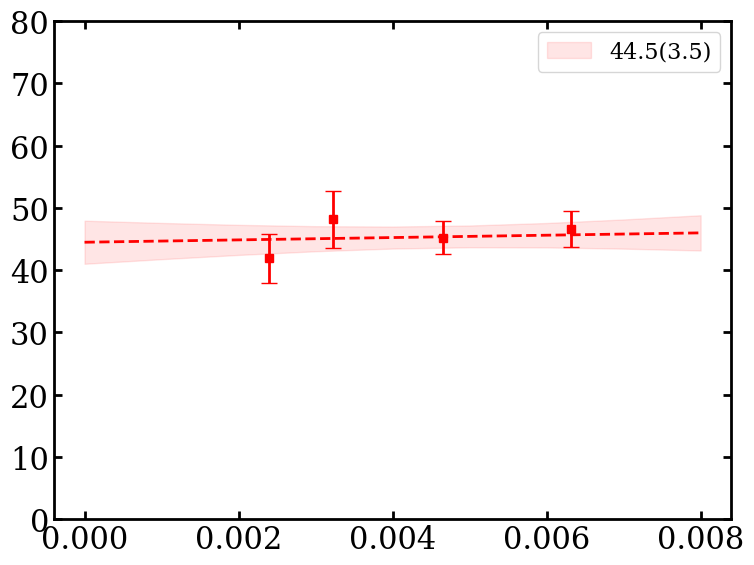

In [13]:
ens2sgm={}
def run(tfphy,tcphy):
    labels=['2st2step_SYM']
    fig,axs=yu.getFigAxs(1,len(labels),sharex=True,sharey=True)
    axs[0,0].set_ylim(ylim_global)
    for ilabel,label in enumerate(labels):
        ax=axs[0,ilabel]
        
        ens2dat={}
        ens2fitlabel={}
        for ens in enss:
            m,e=dic_sgm_ChPT[(yu.ens2label[ens],'ratio_N3LO')]
            # factor=yu.ens2amul[ens]*yu.ens2aInv[ens]*yu.jackknife_pseudo(m,e,ens2Njk[ens])[:,0]
            factor=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]
            fits=yu.getFits(f'{g}_{ens}_{label}{app}_{symmetrizeQ}')
            ind=np.argmin([np.abs(tfmin-tfphy/yu.ens2a[ens]) + np.abs(tcmin - tcphy/yu.ens2a[ens] ) for (tfmin,tcmin),*_ in fits])
            fit=fits[ind]
            ens2fitlabel[ens]=fit[0]
            
            ens2sgm[ens]=fit[1][:,0]*yu.ens2amul[ens]*yu.ens2aInv[ens]
            
            dat=fit[1][:,0]*factor
            ens2dat[ens]=dat
            
            print(ens,yu.jackme_un2str(dat))
            
            mean,err=yu.jackme(dat)
            ax.errorbar(yu.ens2a[ens]**2,mean,err,color='r')
            
        fits=yu.doFits_continuumExtrapolation(ens2dat,lat_a2s_plt=yuc.lat_a2s_plt,supjackQ=False,fitlabels=['const','linear','const-1'])
        
        color='r'
        (pars_mean_MA,pars_err_MA,probs,pars_err_MA_stats,pars_err_MA_systs)=yu.modelAvg(fits,jackInputQ=False,fullOutputQ=True)
        mean,err=pars_mean_MA,pars_err_MA
        x=yuc.lat_a2s_plt; ymin=mean-err; ymax=mean+err
        ax.plot(x,mean,color=color,linestyle='--',marker='')
        ax.fill_between(x, ymin, ymax, color=color, alpha=0.1,label=f'{yu.un2str(mean[0],err[0])}')
        
        ax.legend()
    yu.finalizePlot('CE_selected',closeQ=False)
    
run(tfphy,tcphy)
yu.save_pkl_reg('ens2sgm',ens2sgm)

In [11]:
ens2sgm['b'].shape

(725,)